**What is the Medallion Architecture?**
This is a data organization pattern with three layers:

- **Bronze (Raw):** Data exactly as it arrived - no transformations. Your source of truth.
- **Silver (Cleaned):** Filtered, cleaned, and enriched data. Business-ready but not aggregated.
- **Gold (Business):** Aggregated, analytics-ready data. ML features, KPIs, dashboards.


In [0]:
# Import all required libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.sql.window import Window
import time


In [0]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, count, sum, avg, min, max, stddev, variance,
    when, lit, concat_ws, regexp_extract, lag, lead,
    window, unix_timestamp, to_timestamp, date_format,
    round as spark_round, expr, percentile_approx,
    countDistinct, first, last, collect_list, size,
    explode, arrays_zip, transform, aggregate
)
from pyspark.sql.types import *
from pyspark.sql.window import Window

# Import ML libraries
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml.clustering import KMeans
from pyspark.ml import Pipeline

# Import Python libraries for analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

In [0]:
# Define the schema to ensure types are correct
schema = StructType([
    StructField("No.", IntegerType(), True),
    StructField("Time", TimestampType(), True),
    StructField("Source", StringType(), True),
    StructField("Destination", StringType(), True),
    StructField("Protocol", StringType(), True),
    StructField("Length", IntegerType(), True),
    StructField("Info", StringType(), True)
])

### **Setup & Data Ingestion:**
We use PySpark to read the file. This is scalable—if my CSV is 100GB, this code would still work, unlike standard Pandas.
## Bronze Layer - Data Ingestion & Streaming Simulation


In [0]:
file_path = "/Volumes/workspace/default/google_meet1/Google_Meet_1.csv"
# 2. Load Data with Schema Inference
# let Spark guess the types
raw_df = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load(file_path)

### Silver (Cleaned)

In [0]:
# 3. Preprocessing: Cleanup Timestamp
# The format in the CSV is usually 'yyyy-MM-dd HH:mm:ss.SSSSSS'
df_clean = raw_df.withColumn("Time", to_timestamp(col("Time"))) \
                 .filter(col("Time").isNotNull()) \
                 .orderBy("Time")

# Display first 5 rows to verify
display(df_clean.limit(5))

No.,Time,Source,Destination,Protocol,Length,Info
2,2022-06-05T07:22:56.535Z,10.215.173.1,142.250.82.120,UDP,66,51603 > 19305 Len=38
5,2022-06-05T07:22:56.583Z,10.215.173.1,142.250.82.120,UDP,70,51603 > 19305 Len=42
6,2022-06-05T07:22:56.623Z,10.215.173.1,142.250.82.120,TCP,60,53687 > 19305 [SYN] Seq=0 Win=65535 Len=0 MSS=1460 SACK_PERM=1 TSval=321461212 TSecr=0 WS=1024
7,2022-06-05T07:22:56.632Z,10.215.173.1,142.250.82.120,TCP,60,34453 > 443 [SYN] Seq=0 Win=65535 Len=0 MSS=1460 SACK_PERM=1 TSval=321461220 TSecr=0 WS=1024
8,2022-06-05T07:22:56.635Z,10.215.173.1,142.250.82.120,UDP,110,51603 > 19305 Len=82


### Dataset Statistics (The "Bird's Eye View")
Goal: Understand what we are looking at. How big is the data? Who is talking to whom? What language (Protocol) are they speaking?

In [0]:
from pyspark.sql.functions import min, max, countDistinct

# 1. Basic Counts
total_packets = df_clean.count()
total_duration_df = df_clean.agg(min("Time").alias("Start"), max("Time").alias("End")).collect()[0]

# 2. Unique "Talkers" (IP Addresses)
unique_sources = df_clean.select("Source").distinct().count()
unique_destinations = df_clean.select("Destination").distinct().count()

# 3. Protocol Distribution (Video vs Control Signals)
protocol_counts = df_clean.groupBy("Protocol").count().orderBy("count", ascending=False)

# --- PRINTING RESULTS ---
print(f"--- 📊 Dataset Statistics ---")
print(f"Total Packets Captured: {total_packets:,}")
print(f"Duration: From {total_duration_df['Start']} to {total_duration_df['End']}")
print(f"Unique Sources: {unique_sources} | Unique Destinations: {unique_destinations}")
print("\n--- Protocol Breakdown ---")
protocol_counts.show()

--- 📊 Dataset Statistics ---
Total Packets Captured: 27,168,965
Duration: From 2022-06-05 07:22:56.535348 to 2022-06-06 07:18:19.803593
Unique Sources: 2 | Unique Destinations: 2

--- Protocol Breakdown ---
+------------+--------+
|    Protocol|   count|
+------------+--------+
|         TCP|26856927|
|        STUN|  243207|
|         UDP|   67536|
|       TLSv1|     606|
|       SSLv2|     289|
|        RTCP|     255|
|        TFTP|     112|
|    DTLSv1.2|      24|
|TURN CHANNEL|       9|
+------------+--------+



### **Feature Engineering (Calculating Telecom KPIs)**
Raw logs are useless. We need to derive KPIs (Key Performance Indicators): Throughput (Bandwidth), Packet Rate, and Jitter.
### Gold (Business)

In [0]:
from pyspark.sql.window import Window

window_spec = Window.orderBy("Time")

# --- LOGIC EXPLANATION ---
# 1. Throughput: Sum of packet bytes per second.
# 2. Packet Rate: Count of packets per second.
# 3. Jitter: The standard deviation of the time gap between consecutive packets (Inter-Arrival Time).

# A. Calculate Inter-Arrival Time (IAT) for Jitter
# We use a Window function to look at the "previous" row's time
window_spec = Window.orderBy("Time")
df_with_lag = df_clean.withColumn("Prev_Time", lag("Time", 1).over(window_spec)) \
                      .withColumn("IAT_Seconds", col("Time").cast("double") - col("Prev_Time").cast("double")) \
                      .fillna(0, subset=["IAT_Seconds"])

# B. Aggregate Metrics by 1-Second Windows
# This reduces millions of raw packets into a clean Time-Series dataset
kpi_df = df_with_lag.groupBy(window("Time", "1 second").alias("Time_Window")) \
    .agg(
        (sum("Length") * 8 / 1_000_000).alias("Throughput_Mbps"),  # Bytes -> Megabits
        count("*").alias("Packet_Rate_PPS"),                       # Packets Per Second
        stddev("IAT_Seconds").alias("Jitter_Seconds")              # Variation in arrival time
    ) \
    .orderBy("Time_Window") \
    .fillna(0) # Handle NaN values in Jitter

print(f"Total Aggregated Data Points: {kpi_df.count()}")
display(kpi_df.limit(5))

Total Aggregated Data Points: 86123


Time_Window,Throughput_Mbps,Packet_Rate_PPS,Jitter_Seconds
"List(2022-06-05T07:22:56.000Z, 2022-06-05T07:22:57.000Z)",0.014448,25,0.018914090674103403
"List(2022-06-05T07:22:57.000Z, 2022-06-05T07:22:58.000Z)",0.066232,70,0.012718061790208965
"List(2022-06-05T07:22:58.000Z, 2022-06-05T07:22:59.000Z)",0.113904,122,0.005944289714846243
"List(2022-06-05T07:22:59.000Z, 2022-06-05T07:23:00.000Z)",0.524896,172,0.005566354194030574
"List(2022-06-05T07:23:00.000Z, 2022-06-05T07:23:01.000Z)",1.242848,270,0.004130600292344392


### Key Matrix Statistics (The Performance Health)
Goal: Analyze the behavior of the network metrics. Are the packets large (Video) or small (Audio)? Is the speed stable?

In [0]:
# 1. Packet Statistics (From Raw Data)
# What is the average size of a packet?
print("--- 📦 Packet Size Statistics (Bytes) ---")
df_clean.select("Length").describe().show()

# 2. Network Performance Stats (From KPI Data)
# How fast is the data moving? (Throughput)
print("--- 🚀 Throughput Statistics (Mbps) ---")
kpi_df.select("Throughput_Mbps").describe().show()

# 3. Jitter Stats (From KPI Data)
# Is the connection stable?
print("--- 〰️ Jitter Statistics (Seconds) ---")
kpi_df.select("Jitter_Seconds").describe().show()

--- 📦 Packet Size Statistics (Bytes) ---
+-------+-----------------+
|summary|           Length|
+-------+-----------------+
|  count|         27168965|
|   mean|462.7371619787504|
| stddev| 537.945494809551|
|    min|               40|
|    max|             1500|
+-------+-----------------+

--- 🚀 Throughput Statistics (Mbps) ---
+-------+-------------------+
|summary|    Throughput_Mbps|
+-------+-------------------+
|  count|              86123|
|   mean|  1.167826458251563|
| stddev|0.32074611214983256|
|    min|           0.014448|
|    max|           2.369904|
+-------+-------------------+

--- 〰️ Jitter Statistics (Seconds) ---
+-------+--------------------+
|summary|      Jitter_Seconds|
+-------+--------------------+
|  count|               86123|
|   mean|0.005527429533317...|
| stddev|0.001742994947887006|
|    min|0.002200549782259793|
|    max|  0.1604115834448675|
+-------+--------------------+



### QoS Assessment (The Final Verdict)
Goal: Translate numbers into words (Good, Fair, Poor) that a non-technical Manager can understand.

In [0]:
from pyspark.sql.functions import when, col, lit

# 1. Define Rules for Quality
# Rule: If Jitter > 0.03s (30ms), it's POOR.
#       If Throughput < 0.5 Mbps (and Jitter is low), it might just be silence/idle, so we call it FAIR.
#       Otherwise, it's GOOD.

qos_df = kpi_df.withColumn("Quality_Category", 
    when(col("Jitter_Seconds") > 0.03, "Poor (High Lag)")
    .when(col("Throughput_Mbps") < 0.1, "Idle/Silence")
    .otherwise("Good (HD Video)")
)

# 2. Calculate the Percentage of Time in Each Category
total_seconds = qos_df.count()

qos_summary = qos_df.groupBy("Quality_Category") \
    .count() \
    .withColumn("Percentage", (col("count") / total_seconds) * 100) \
    .orderBy("Percentage", ascending=False)

print("--- 🏆 Quality of Service (QoS) Assessment ---")
qos_summary.show(truncate=False)

--- 🏆 Quality of Service (QoS) Assessment ---
+----------------+-----+---------------------+
|Quality_Category|count|Percentage           |
+----------------+-----+---------------------+
|Good (HD Video) |86114|99.98954982989446    |
|Poor (High Lag) |5    |0.0058056500586370656|
|Idle/Silence    |4    |0.0046445200469096524|
+----------------+-----+---------------------+



### **Visual Analysis (Business Insights)**
We converted the aggregated data (which is now small) to Pandas to create professional plots.

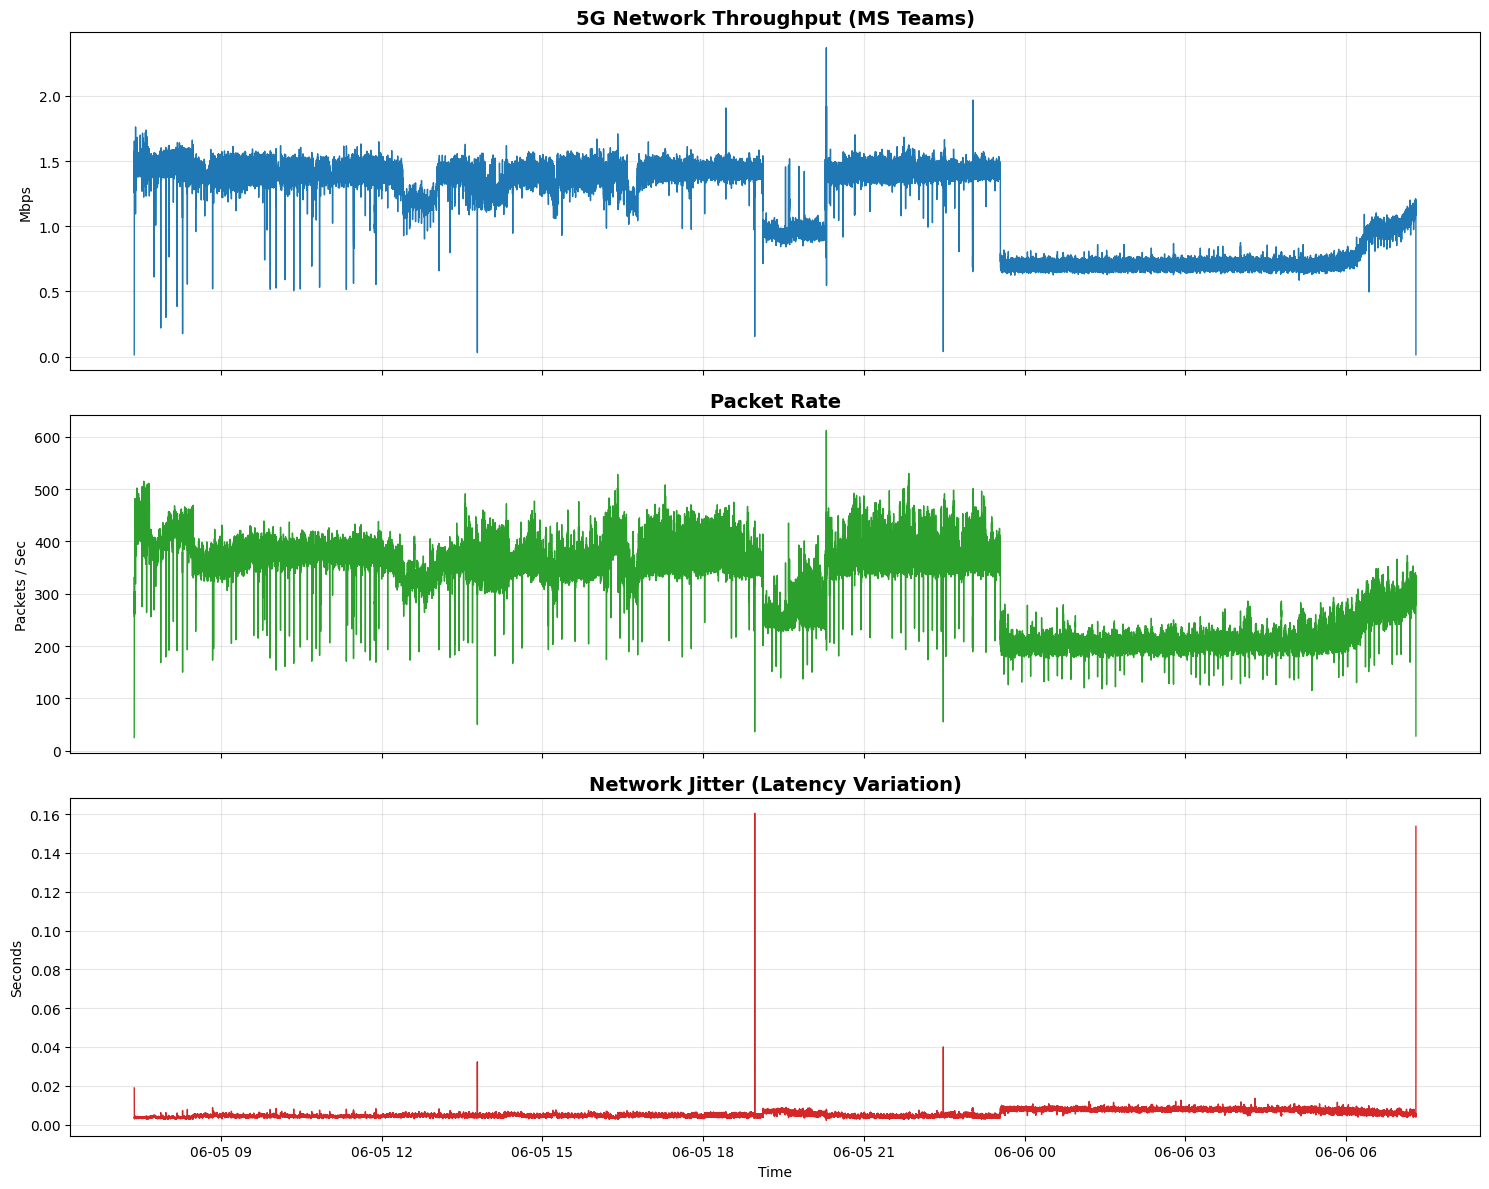

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Convert to Pandas (Safe now because we aggregated data)
pdf = kpi_df.toPandas()

# Extract 'Time' from the dict returned by window()
pdf['Time'] = pdf['Time_Window'].apply(lambda x: x['start'])
pdf = pdf.set_index('Time')

# 2. Plotting
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# Plot Throughput
axes[0].plot(pdf.index, pdf['Throughput_Mbps'], color='#1f77b4', linewidth=1)
axes[0].set_title('5G Network Throughput (MS Teams)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Mbps')
axes[0].grid(True, alpha=0.3)

# Plot Packet Rate
axes[1].plot(pdf.index, pdf['Packet_Rate_PPS'], color='#2ca02c', linewidth=1)
axes[1].set_title('Packet Rate', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Packets / Sec')
axes[1].grid(True, alpha=0.3)

# Plot Jitter
axes[2].plot(pdf.index, pdf['Jitter_Seconds'], color='#d62728', linewidth=1)
axes[2].set_title('Network Jitter (Latency Variation)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Seconds')
axes[2].set_xlabel('Time')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show() # In Databricks, this renders the plot inline

### **Machine Learning (Anomaly Detection)**
We trained an Unsupervised Learning model (Isolation Forest) to automatically find "bad network moments" without needing labeled data.

Detected 86 anomalies out of 86123 time windows.


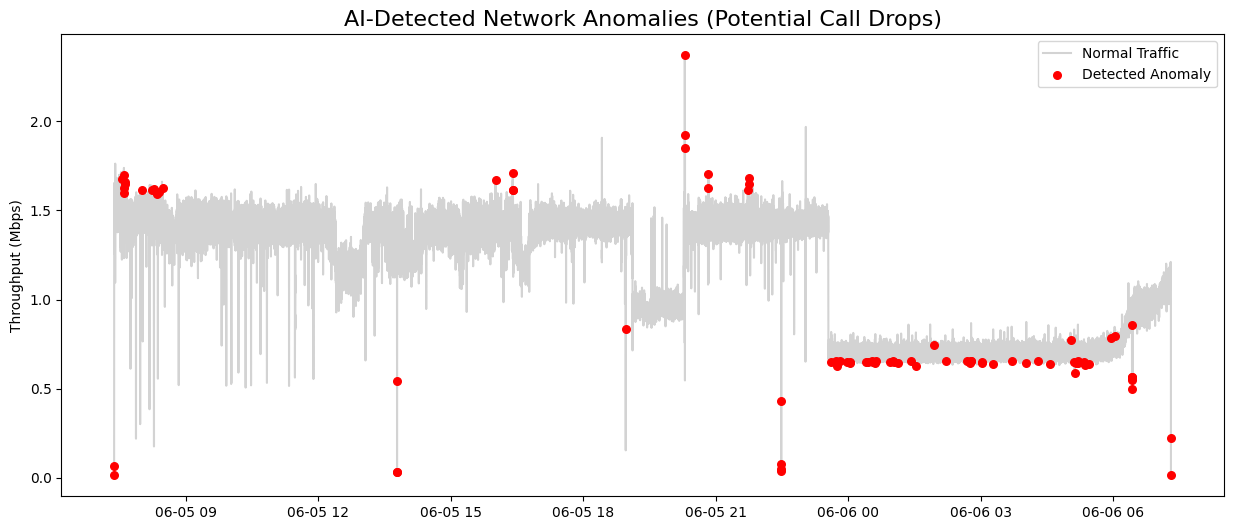

Time,Time_Window,Throughput_Mbps,Packet_Rate_PPS,Jitter_Seconds,Anomaly
2022-06-05T07:22:56.000Z,"List(2022-06-05T07:22:57.000, 2022-06-05T07:22:56.000)",0.014448,25,0.018914090674103403,-1
2022-06-05T07:22:57.000Z,"List(2022-06-05T07:22:58.000, 2022-06-05T07:22:57.000)",0.066232,70,0.012718061790208965,-1
2022-06-05T07:32:59.000Z,"List(2022-06-05T07:33:00.000, 2022-06-05T07:32:59.000)",1.676216,455,0.0031942765113967034,-1
2022-06-05T07:36:07.000Z,"List(2022-06-05T07:36:08.000, 2022-06-05T07:36:07.000)",1.6996,449,0.003173496732230605,-1
2022-06-05T07:36:39.000Z,"List(2022-06-05T07:36:40.000, 2022-06-05T07:36:39.000)",1.598504,485,0.0029777626668068095,-1
2022-06-05T07:36:54.000Z,"List(2022-06-05T07:36:55.000, 2022-06-05T07:36:54.000)",1.62816,497,0.003047321052278441,-1
2022-06-05T07:37:15.000Z,"List(2022-06-05T07:37:16.000, 2022-06-05T07:37:15.000)",1.657568,508,0.003195284912211414,-1
2022-06-05T07:37:34.000Z,"List(2022-06-05T07:37:35.000, 2022-06-05T07:37:34.000)",1.649912,508,0.003163944618849394,-1
2022-06-05T08:01:23.000Z,"List(2022-06-05T08:01:24.000, 2022-06-05T08:01:23.000)",1.61208,457,0.002998429415882131,-1
2022-06-05T08:14:23.000Z,"List(2022-06-05T08:14:24.000, 2022-06-05T08:14:23.000)",1.612568,440,0.0031609497548576683,-1


In [0]:
from sklearn.ensemble import IsolationForest
import numpy as np

# 1. Prepare Data for ML
# We use Throughput and Jitter as features to detect anomalies
features = ['Throughput_Mbps', 'Jitter_Seconds']
X = pdf[features].values

# 2. Train Model
# contamination=0.01 means we expect ~1% of the data to be anomalies
model = IsolationForest(contamination=0.001, random_state=42)
pdf['Anomaly'] = model.fit_predict(X) 

# Result: -1 is Anomaly, 1 is Normal
anomalies = pdf[pdf['Anomaly'] == -1]

print(f"Detected {len(anomalies)} anomalies out of {len(pdf)} time windows.")

# 3. Visualize Anomalies
plt.figure(figsize=(15, 6))
plt.plot(pdf.index, pdf['Throughput_Mbps'], label='Normal Traffic', color='lightgray')
plt.scatter(anomalies.index, anomalies['Throughput_Mbps'], color='red', label='Detected Anomaly', s=30, zorder=5)
plt.title('AI-Detected Network Anomalies (Potential Call Drops)', fontsize=16)
plt.ylabel('Throughput (Mbps)')
plt.legend()
plt.show()

# 4. Display the detailed anomaly records
display(spark.createDataFrame(anomalies.reset_index()))